In [11]:
import pandas as pd
import numpy as np

BASE_PATH = r'C:\Users\harsh\OneDrive\Desktop\ipl data analysis\datanew'
matches = pd.read_csv(rf'{BASE_PATH}\matches_clean.csv', parse_dates=['match_date'])
deliveries = pd.read_csv(rf'{BASE_PATH}\deliveries_clean.csv')

# ── Base dataframe (same as before) ──────────────────────────────────────────
matches_ml = matches[(matches['match_winner'].notna()) & 
                     (matches['season'] != 2026)].copy()

team1 = matches_ml[['match_id', 'season', 'match_date', 'venue',
                     'team1', 'team2', 'toss_winner', 'match_winner']].copy()
team1['team'] = team1['team1']
team1['opponent'] = team1['team2']
team1['won'] = (team1['match_winner'] == team1['team1']).astype(int)

team2 = matches_ml[['match_id', 'season', 'match_date', 'venue',
                     'team1', 'team2', 'toss_winner', 'match_winner']].copy()
team2['team'] = team2['team2']
team2['opponent'] = team2['team1']
team2['won'] = (team2['match_winner'] == team2['team2']).astype(int)

base = pd.concat([team1, team2], ignore_index=True)
base['toss_won'] = (base['toss_winner'] == base['team']).astype(int)
base = base.sort_values(['match_date', 'match_id']).reset_index(drop=True)

# ── Previous features ─────────────────────────────────────────────────────────
def rolling_win_pct(df, window=5):
    results = []
    for team, group in df.groupby('team'):
        group = group.sort_values('match_date').copy()
        group['form'] = group['won'].shift(1).rolling(window, min_periods=1).mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

def h2h_win_pct(df):
    results = []
    for (team, opponent), group in df.groupby(['team', 'opponent']):
        group = group.sort_values('match_date').copy()
        group['h2h_win_pct'] = group['won'].shift(1).expanding().mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

def venue_win_pct(df):
    results = []
    for (team, venue), group in df.groupby(['team', 'venue']):
        group = group.sort_values('match_date').copy()
        group['venue_win_pct'] = group['won'].shift(1).expanding().mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

def overall_win_rate(df):
    results = []
    for team, group in df.groupby('team'):
        group = group.sort_values('match_date').copy()
        group['overall_win_rate'] = group['won'].shift(1).expanding().mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

def season_win_rate(df):
    results = []
    for (team, season), group in df.groupby(['team', 'season']):
        group = group.sort_values('match_date').copy()
        group['season_win_rate'] = group['won'].shift(1).expanding().mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

base = rolling_win_pct(base)
base = h2h_win_pct(base)
base = venue_win_pct(base)
base = overall_win_rate(base)
base = season_win_rate(base)

base['form'] = base['form'].fillna(0.5)
base['h2h_win_pct'] = base['h2h_win_pct'].fillna(0.5)
base['venue_win_pct'] = base['venue_win_pct'].fillna(0.5)
base['overall_win_rate'] = base['overall_win_rate'].fillna(0.5)
base['season_win_rate'] = base['season_win_rate'].fillna(0.5)

base['team_enc'] = base['team'].astype('category').cat.codes
base['opponent_enc'] = base['opponent'].astype('category').cat.codes

# ── Deliveries setup ──────────────────────────────────────────────────────────
d = deliveries[
    (deliveries['innings'].isin([1, 2])) &
    (deliveries['is_wide_ball'] == False) &
    (deliveries['is_no_ball'] == False) &
    (deliveries['is_super_over'] == False)
].copy()

def get_phase(over):
    if over <= 5:
        return 'powerplay'
    elif over <= 14:
        return 'middle'
    else:
        return 'death'

d['phase'] = d['over_number'].apply(get_phase)

# ── Matchup features ──────────────────────────────────────────────────────────
# Merge deliveries with match info to get opponent
d = d.merge(
    matches_ml[['match_id', 'match_date', 'team1', 'team2']],
    on='match_id', how='left'
)

# For each delivery, opponent = the other team
d['opponent'] = d.apply(
    lambda x: x['team_bowling'] if x['team_batting'] == x['team1'] 
    else x['team_batting'], axis=1
)

# Phase-wise runs per match per team pair
phase_runs = (d.groupby(['match_id', 'match_date', 'team_batting', 'opponent', 'phase'])
              ['batter_runs'].sum().reset_index())
phase_runs.columns = ['match_id', 'match_date', 'team', 'opponent', 'phase', 'runs']

# Phase-wise wickets per match per team pair (bowling perspective)
phase_wickets = (d[d['is_wicket'] == True]
                 .groupby(['match_id', 'match_date', 'team_bowling', 'opponent', 'phase'])
                 ['is_wicket'].sum().reset_index())
phase_wickets.columns = ['match_id', 'match_date', 'team', 'opponent', 'phase', 'wickets']

# Historical average phase runs per team-opponent pair (with shift to avoid leakage)
def h2h_phase_avg(df, value_col, new_col_prefix):
    results = []
    for (team, opponent, phase), group in df.groupby(['team', 'opponent', 'phase']):
        group = group.sort_values('match_date').copy()
        group[f'{new_col_prefix}_{phase}'] = group[value_col].shift(1).expanding().mean()
        results.append(group)
    return pd.concat(results).sort_values(['match_date', 'match_id'])

phase_runs = h2h_phase_avg(phase_runs, 'runs', 'h2h_runs')
phase_wickets = h2h_phase_avg(phase_wickets, 'wickets', 'h2h_wkts')

# ── Merge phase features separately (fixes median overwrite bug) ──────────────
base = base.drop(columns=[c for c in base.columns if c.endswith('_x') or c.endswith('_y')], errors='ignore')

new_cols = ['h2h_runs_powerplay', 'h2h_runs_middle', 'h2h_runs_death',
            'h2h_wkts_powerplay', 'h2h_wkts_middle', 'h2h_wkts_death']

for phase in ['powerplay', 'middle', 'death']:
    # Runs
    runs_phase = (phase_runs[phase_runs['phase'] == phase]
                  [['match_id', 'team', 'opponent', f'h2h_runs_{phase}']]
                  .drop_duplicates())
    base = base.merge(runs_phase, on=['match_id', 'team', 'opponent'], how='left')

    # Wickets
    wkts_phase = (phase_wickets[phase_wickets['phase'] == phase]
                  [['match_id', 'team', 'opponent', f'h2h_wkts_{phase}']]
                  .drop_duplicates())
    base = base.merge(wkts_phase, on=['match_id', 'team', 'opponent'], how='left')

# Fill with forward fill per team-opponent group first
base = base.sort_values(['match_date', 'match_id']).reset_index(drop=True)

for col in new_cols:
    base[col] = (base.groupby(['team', 'opponent'])[col]
                 .transform(lambda x: x.ffill()))
# Any remaining NaN (truly no prior history) fill with median
for col in new_cols:
    base[col] = base[col].fillna(base[col].median())

# Verify CSK vs RCB
csk_rcb = base[(base['team'] == 'Chennai Super Kings') &
               (base['opponent'] == 'Royal Challengers Bangalore')]
print(csk_rcb[['match_date', 'h2h_runs_powerplay', 'h2h_runs_death', 'h2h_wkts_powerplay']].head(15))

print(base.shape)
print(base[new_cols].isnull().sum())

    match_date  h2h_runs_powerplay  h2h_runs_death  h2h_wkts_powerplay
28  2008-04-28           42.299107       42.928571            1.833333
90  2008-05-21           42.299107       42.928571            1.833333
124 2009-04-20           42.299107       42.928571            1.833333
198 2009-05-14           42.299107       42.928571            1.833333
226 2009-05-23           42.299107       42.928571            1.833333
264 2010-03-23           42.299107       42.928571            1.833333
284 2010-03-31           33.000000       17.000000            2.000000
376 2011-04-16           43.500000       20.000000            1.500000
484 2011-05-22           43.500000       20.000000            1.500000
488 2011-05-24           43.500000       20.000000            1.500000
494 2011-05-28           43.666667       32.333333            2.000000
520 2012-04-12           45.250000       34.750000            2.000000
674 2013-04-13           46.400000       41.400000            1.800000
782 20

Train size: 2048 | Test size: 290

Random Forest
Accuracy: 0.4966 | ROC-AUC: 0.4575
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       145
           1       0.50      0.46      0.47       145

    accuracy                           0.50       290
   macro avg       0.50      0.50      0.50       290
weighted avg       0.50      0.50      0.50       290


XGBoost
Accuracy: 0.4793 | ROC-AUC: 0.4801
              precision    recall  f1-score   support

           0       0.48      0.52      0.50       145
           1       0.48      0.44      0.46       145

    accuracy                           0.48       290
   macro avg       0.48      0.48      0.48       290
weighted avg       0.48      0.48      0.48       290


Logistic Regression (scaled)
Accuracy: 0.4310 | ROC-AUC: 0.4565
              precision    recall  f1-score   support

           0       0.44      0.46      0.45       145
           1       0.43      0.40      0.41 

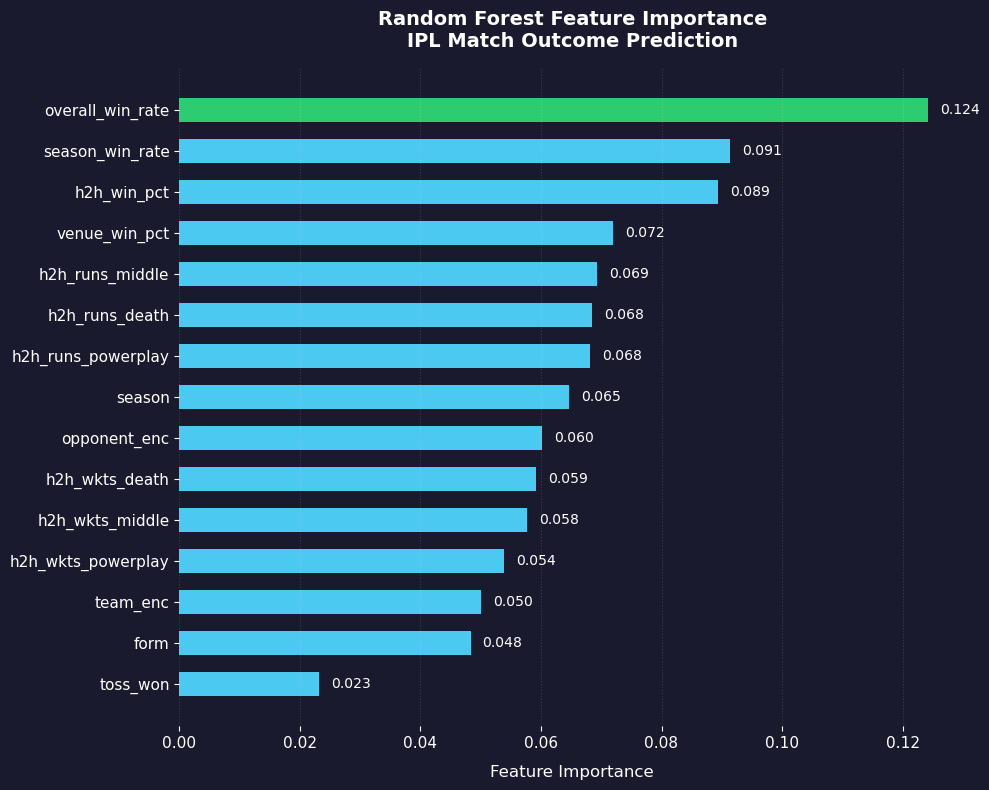


Model saved.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import joblib

features = ['team_enc', 'opponent_enc', 'toss_won', 'form',
            'h2h_win_pct', 'venue_win_pct', 'season',
            'overall_win_rate', 'season_win_rate',
            'h2h_runs_powerplay', 'h2h_runs_middle', 'h2h_runs_death',
            'h2h_wkts_powerplay', 'h2h_wkts_middle', 'h2h_wkts_death']
target = 'won'

X = base[features]
y = base[target]

test_seasons = [2024, 2025]
train_idx = base[~base['season'].isin(test_seasons)].index
test_idx = base[base['season'].isin(test_seasons)].index

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results[name] = {'accuracy': acc, 'roc_auc': auc, 'model': model}
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, preds))

# Logistic Regression separately with scaling
lr = LogisticRegression(max_iter=5000, solver='saga')
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)
results['Logistic Regression'] = {'accuracy': lr_acc, 'roc_auc': lr_auc, 'model': lr}
print(f"\nLogistic Regression (scaled)")
print(f"Accuracy: {lr_acc:.4f} | ROC-AUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_preds))

# Feature importance from Random Forest
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    models['Random Forest'].feature_importances_,
    index=features
).sort_values(ascending=True)

print("\nFeature Importance:")
print(feat_imp)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = ['#2ecc71' if v == feat_imp.max() else '#4cc9f0' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.3f}",
            va='center', ha='left', fontsize=10, color='white')

ax.set_xlabel('Feature Importance', fontsize=12, color='white', labelpad=10)
ax.set_title('Random Forest Feature Importance\nIPL Match Outcome Prediction',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(colors='white', labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.15, color='white')
plt.tight_layout()
plt.savefig('plots/11_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

# Save best model (Random Forest) and scaler
best_model = models['Random Forest']
joblib.dump(best_model, rf'{BASE_PATH}\rf_model.pkl')
joblib.dump(scaler, rf'{BASE_PATH}\scaler.pkl')
joblib.dump(features, rf'{BASE_PATH}\features.pkl')
print("\nModel saved.")

In [13]:
matches_2026 = matches[matches['season'] == 2026].copy()
print(f"Total 2026 matches in dataset: {len(matches_2026)}")
print(f"Completed: {matches_2026['match_winner'].notna().sum()}")
print(f"Remaining: {matches_2026['match_winner'].isna().sum()}")
print(matches_2026[['match_date', 'team1', 'team2', 'match_winner']].tail(20))

Total 2026 matches in dataset: 43
Completed: 43
Remaining: 0
     match_date                        team1                        team2  \
1192 2026-04-16               Mumbai Indians                 Punjab Kings   
1193 2026-04-17        Kolkata Knight Riders               Gujarat Titans   
1194 2026-04-18  Royal Challengers Bangalore               Delhi Capitals   
1195 2026-04-18          Sunrisers Hyderabad          Chennai Super Kings   
1196 2026-04-19             Rajasthan Royals        Kolkata Knight Riders   
1197 2026-04-19                 Punjab Kings         Lucknow Super Giants   
1198 2026-04-20               Mumbai Indians               Gujarat Titans   
1199 2026-04-21          Sunrisers Hyderabad               Delhi Capitals   
1200 2026-04-22             Rajasthan Royals         Lucknow Super Giants   
1201 2026-04-23          Chennai Super Kings               Mumbai Indians   
1202 2026-04-24               Gujarat Titans  Royal Challengers Bangalore   
1203 2026-04-25